In [4]:
#Irem_Dogruoglu_7061348_Lizzie_Schmitz_7056551
#References:
#1.https://matplotlib.org/stable/tutorials/introductory/pyplot.html
#2.https://github.com/gnina/gnina
#3.https://github.com/RMeli/gnina-torch
#This notebook creates outputs for docking, retraining, and analysis with GNINA-Torch.
#It loads the outputs from the main pipeline and visualizes the key metrics on the proto_test benchmark.

In [5]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import re
import numpy as np

#Getting the right directories for inputs and outputs. 
RESULTS_PT = Path("results")
MODEL_DIR = RESULTS_PT / "gninatorch_training"
REDO_MODEL_DIR = RESULTS_PT / "proto_test_retrained"
PLOTS_DIR = RESULTS_PT / "plots"

PLOTS_DIR.mkdir(parents=True, exist_ok=True)

#Creating loop to generate metrics for all trained model directories.
trained_model_dirs = [d for d in MODEL_DIR.iterdir() if d.is_dir()]

MODEL_DIR, REDO_MODEL_DIR, PLOTS_DIR, trained_model_dirs

(PosixPath('results/gninatorch_training'),
 PosixPath('results/proto_test_retrained'),
 PosixPath('results/plots'),
 [PosixPath('results/gninatorch_training/default2018_seed1'),
  PosixPath('results/gninatorch_training/dense_seed1')])

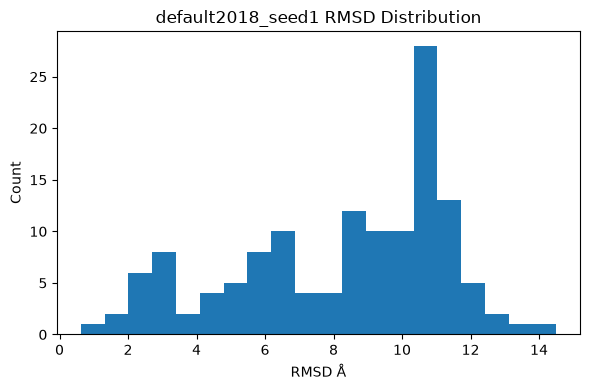

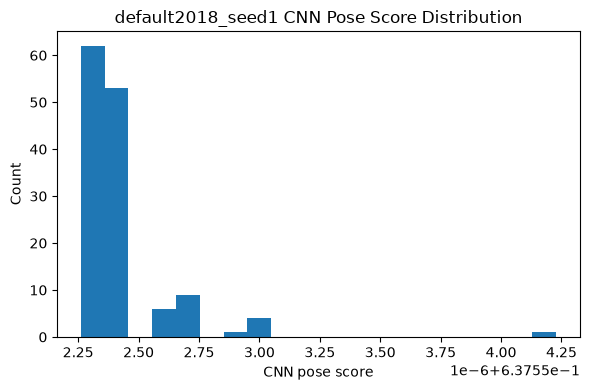

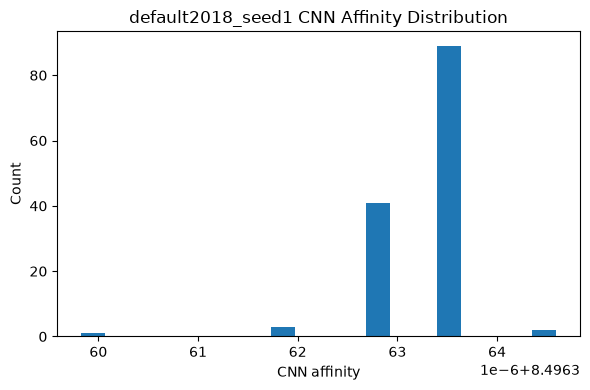

default2018_seed1: Percentage of complexes that has RMSD <= 2 Å: 2.21%


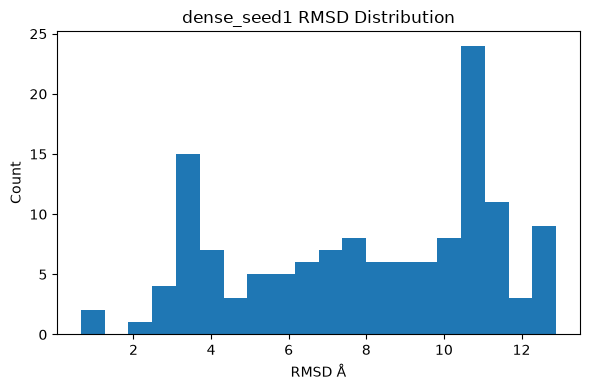

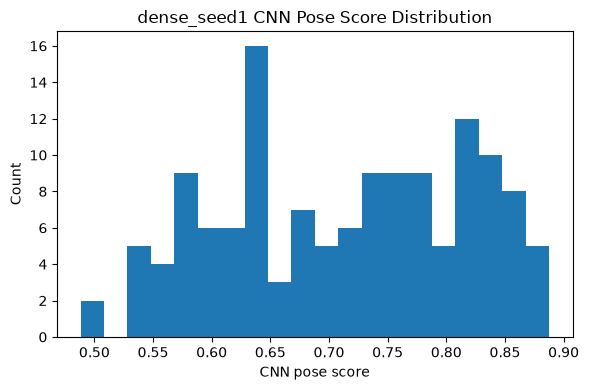

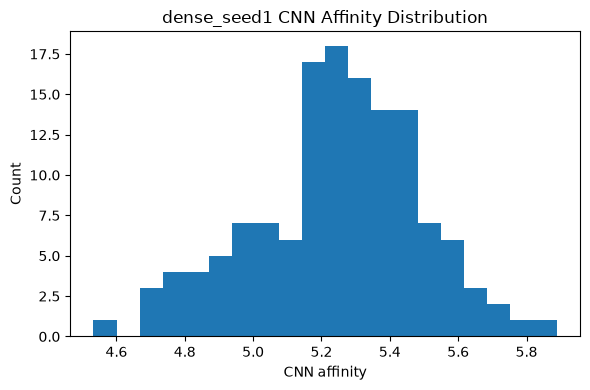

dense_seed1: Percentage of complexes that has RMSD <= 2 Å: 1.47%


In [6]:
for model_dir in trained_model_dirs:
    model_name = model_dir.name

    #Getting the metrics CSV file.
    metrics_csv = PLOTS_DIR / f"{model_name}_metrics.csv"
    metrics = pd.read_csv(metrics_csv)
    metrics.head()

    #RMSD distribution plot for retrained GNINA shows distribution of the best pose RMSD values.
    vals_rmsd = [v for v in metrics["rmsd"] if pd.notna(v)]
    plt.figure(figsize=(6,4))
    plt.hist(vals_rmsd, bins=20)
    plt.title(f"{model_name} RMSD Distribution")
    plt.xlabel("RMSD Å")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()

    #Retrained GNINA CNN pose score distribution shows the best CNN pose scores on the proto_test set where higher values mean the pose is more likely to be close to the true binding mode.
    vals_ps = [v for v in metrics["best_cnn_pose_score"] if pd.notna(v)]
    plt.figure(figsize=(6,4))
    plt.hist(vals_ps, bins=20)
    plt.title(f"{model_name} CNN Pose Score Distribution")
    plt.xlabel("CNN pose score")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()

    #Retrained GNINA CNN affinity distribution indicates in higher values relates to stronger predicted binding affinity between ligand and receptor.
    vals_aff = [v for v in metrics["best_cnn_affinity"] if pd.notna(v)]
    plt.figure(figsize=(6,4))
    plt.hist(vals_aff, bins=20)
    plt.title(f"{model_name} CNN Affinity Distribution")
    plt.xlabel("CNN affinity")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()

    #Generating more detailed RMSD metrics.
    good_vals = metrics["rmsd"] <= 2.0
    good_rate = good_vals.mean()
    print(f"{model_name}: Percentage of complexes that has RMSD <= 2 Å: {good_rate:.2%}")

In [7]:
#Figures explanations:
#The RMSD histograms for both retrained GNINA models reveal that only a tiny percentage of proto_test complexes fall below the good pose threshold of 2 Å, and majority are docked with quite high RMSD values. For roughly 1.47% of complexes, the dense_seed1 model achieves an RMSD ≤ 2 Å, whereas default2018_seed1 reaches about 2.21%. Therefore, default2018_seed1 performs better on this Top-1 success criterion.
#The CNN pose score histograms provide an overview of the GNINA CNN's level of accuracy in the top-ranked poses' quality. The majority of proto_test complexes get midrange pose scores rather than continuously very high values for both dense_seed1 and default2018_seed1, suggesting that the network does not substantially favour a small range of obviously "correct" postures. While default2018_seed1 focuses more mass in a small range, that is aligned with its slightly larger fraction of low-RMSD poses and signals that its scores are more adjusted for this dataset, the dense_seed1 model has wider spread of pose scores.
#The expected binding strengths for each complex's optimal poses are displayed in the CNN affinity histograms. The majority of ligands are given comparable affinities despite their varied RMSD values because both models generate relatively narrow affinity distributions. The default2018_seed1 model has a slightly shifted and more concentrated peak that corresponds to its RMSD ≤ 2 Å rate, but the dense_seed1 model's affinities are centred around a single primary peak. These figures indicate that while the total range of predicted affinities is similar between the two models, changes in the training setting primarily impact pose quality (RMSD) and pose-score calibration.

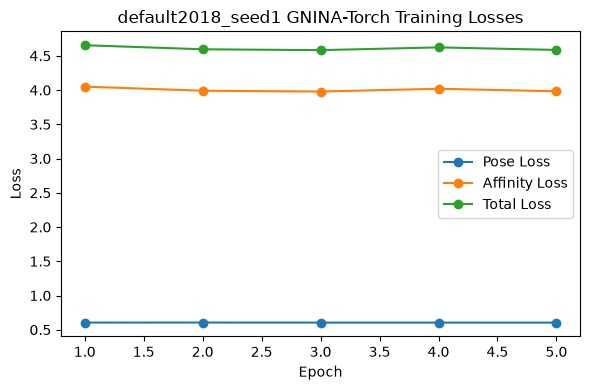

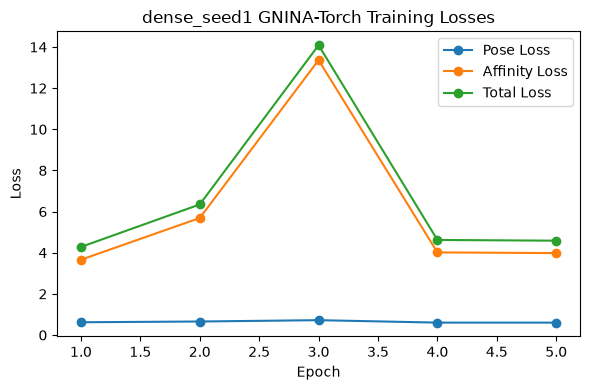

In [8]:
#GNINA-Torch training and test pose loss plot shows how the pose loss evolves over epochs for the training and the test metrics, which enables whether the retrained model is learning and are there overfittings.
def log_metrics_train(log_fl: Path):
    metrics = {}
    if not log_fl.exists(): # error handling 
        print(f"skipping: training log not found: {log_fl}")
        return metrics

    key_map = { # dict structure
        "Accuracy": "accuracy",
        "Balanced Accuracy": "balanced_accuracy",
        "Pose Loss": "pose_loss",
        "ROC AUC": "roc_auc",
        "MAE": "mae",
        "RMSE": "rmse",
        "Affinity Loss": "affinity_loss",
        "Loss": "loss",
        "Epoch Time": "epoch_time",
        "Elapsed Time": "elapsed_time",
    }

    updated_epch = None

    with log_fl.open(errors="ignore") as f:
        for line in f:
            line = line.strip()

            # use regex expressions for flexibility while parsing metrics
            # find the training results per epoch (find headers)
            train_mtc = re.search(  
                r">>>\s*Train Results\s*-\s*Epoch\[(\d+)\]",
                line,
                re.IGNORECASE,
            )
            if train_mtc: # if there is a header line, create a new dict entry for the metrics of each training epoch
                updated_epch = int(train_mtc.group(1))
                metrics[updated_epch] = {}
                continue

            if updated_epch is None:
                continue

            metric_mtch = re.match( # for each line, find out if a metric in the dict is mentioned
                r"(.+?):\s*([-+]?\d*\.?\d+(?:[eE][-+]?\d+)?)",
                line,
            )
            if metric_mtch: # get the titles (raw_key) of each line and its contents (value)
                raw_key = metric_mtch.group(1).strip()
                value = float(metric_mtch.group(2))
                if raw_key in key_map: # if the raw_key is a valid metric in the dict, put the metric and its value into the metrics dict
                    metrics[updated_epch][key_map[raw_key]] = value

    return metrics

#Iretaring over each trained model directory.
for model_dir in trained_model_dirs: 
    model_name = model_dir.name # either dense or default2018 model

    log_fl = model_dir / "training.log"
    metrics_log = log_metrics_train(log_fl)

    epochs = sorted(metrics_log.keys()) # sort by epoch dict
    pose_loss = [metrics_log[e]["pose_loss"] for e in epochs if "pose_loss" in metrics_log[e]]
    affinity_loss = [metrics_log[e]["affinity_loss"] for e in epochs if "affinity_loss" in metrics_log[e]]
    total_loss = [metrics_log[e]["loss"] for e in epochs if "loss" in metrics_log[e]]

    plt.figure(figsize=(6,4))
    if pose_loss:
        plt.plot(epochs, pose_loss, marker="o", label="Pose Loss")
    if affinity_loss:
        plt.plot(epochs, affinity_loss, marker="o", label="Affinity Loss")
    if total_loss:
        plt.plot(epochs, total_loss, marker="o", label="Total Loss")

    plt.title(f"{model_name} GNINA-Torch Training Losses")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.tight_layout()
    plt.show()

In [9]:
#Figures explanation:
#The GNINA-Torch training curves for the dense_seed1 model illustrate the progress of pose loss, affinity loss, and total loss over the course of our five epochs. While affinity and total loss rise rapidly around epoch 4 before declining once more at epoch 5, pose loss remains very low and fluctuates just slightly. This pattern implies that the model may still be under-trained or sensitive to learning-rate and optimisation settings because the brief training session did not reach a stable minimum. Also, dense_seed1's poorer RMSD performance on proto_test may be due to the fact that it hasn't fully converged within this few epochs.
#The default2018_seed1 model exhibits a similar general pattern, with affinity/total loss spiking in the middle of training and pose loss staying low. The curves' amplitude and form, are slightly different from dense_seed1: the ultimate losses are smaller and the primary loss peak happens one epoch earlier. The larger fraction of proto_test complexes with RMSD ≤ 2 Å suggests that default2018_seed1 is learning a little more effectively under the same training schedule. When taken as a whole, the two charts imply that increasing training and fine-tuning hyperparameters could further distinguish the models' performance and lower overall docking losses.

In [10]:
#Best and worst proto_test predictions per model tables. The tables below display a few complexes with the lowest and highest RMSD for each retrained GNINA model, along with their CNN posture and affinity scores. This helps in determining the areas in which each model succeeds or fails.
best_k = 3
worst_k = 3

#Looping the models to get metrics.
for model_dir in trained_model_dirs:
    model_name = model_dir.name
    metrics_csv = PLOTS_DIR / f"{model_name}_metrics.csv"
    metrics = pd.read_csv(metrics_csv)

    print(f"\n{model_name}: Best 3 predictions with lowest RMSD:")
    good_df = metrics.sort_values("rmsd").head(best_k)[
        ["dataset", "complex_id", "rmsd", "best_cnn_pose_score", "best_cnn_affinity"]
    ]
    display(good_df)

    print(f"\n{model_name}: Worst 3 predictions with highest RMSD:")
    bad_df = metrics.sort_values("rmsd", ascending=False).head(worst_k)[
        ["dataset", "complex_id", "rmsd", "best_cnn_pose_score", "best_cnn_affinity"]
    ]
    display(bad_df)


default2018_seed1: Best 3 predictions with lowest RMSD:


,dataset,complex_id,rmsd,best_cnn_pose_score,best_cnn_affinity
9,default2018_seed1,5qu0_QMV_A_601,0.625072,0.637552,8.496362
0,default2018_seed1,3ix2_AC2_A_302,1.565650,0.637552,8.496364
8,default2018_seed1,5qtz_QMY_A_601,1.581800,0.637552,8.496364



default2018_seed1: Worst 3 predictions with highest RMSD:


,dataset,complex_id,rmsd,best_cnn_pose_score,best_cnn_affinity
105,default2018_seed1,5s7t_LU8_A_501,14.5012,0.637552,8.496364
54,default2018_seed1,5s7e_LU8_A_501,13.7277,0.637553,8.496364
107,default2018_seed1,5s7t_LU8_B_501,12.8310,0.637552,8.496364



dense_seed1: Best 3 predictions with lowest RMSD:


,dataset,complex_id,rmsd,best_cnn_pose_score,best_cnn_affinity
19,dense_seed1,5rhd_US7_A_408,0.645939,0.852143,5.175552
120,dense_seed1,5s7x_LU8_A_508,0.792179,0.758847,5.016589
61,dense_seed1,5s7h_LU8_B_501,2.247530,0.574456,4.803226



dense_seed1: Worst 3 predictions with highest RMSD:


,dataset,complex_id,rmsd,best_cnn_pose_score,best_cnn_affinity
70,dense_seed1,5s7j_LU8_B_501,12.8943,0.623787,5.332940
109,dense_seed1,5s7u_LU8_A_507,12.7429,0.776086,5.496107
34,dense_seed1,5s78_LU8_B_501,12.6995,0.632479,5.060533


In [11]:
#Interpretating the best and worst proto_test predictions:
#The best-case rows indicate that the two retrained GNINA models can generate very accurate postures for at least some proto_test complexes: the lowest RMSD values for default2018_seed1 and dense_seed1 are between 0.6 and 1.6 Å, which is below the treshold. The network works well in these poses and evaluates them as good binders, as evidenced by the relatively high CNN pose scores and restricted range of CNN affinities in these top examples.
#With RMSD values exceeding 12 Å for both models, the worst-case rows show the samples that can contain the largest error-rates. It's interesting to note that a large number of the worst complexes are part of the same LU8 series, indicating that this chemotype is not random noise but rather consistently challenging for the current training setup. The CNN pose scores and affinities in the failure cases are not significantly lower than in the best cases despite these large RMSD values, indicating that the scoring function occasionally gives geometrically wrong poses high confidence.
#When comparing the two models, we can see that default2018_seed1 and dense_seed1 exhibit a similar pattern by they both struggle on LU8-like environments and have a limited group of extremely strong predictions along with a cluster of huge outliers. This aligns with the findings from the global histograms and training curves, although the models can learn possible poses for a variety of complexes, the current loss configuration and small training scale are still insufficient to consistently differentiate between good and bad poses across all chemotypes, particularly for the most difficult ligands.

In [12]:
#Summary metrics for every GNINA model that has been retrained are shown in this table. One model directory in gninatorch_training belongs to each row.
all_sums = []

for model_dir in trained_model_dirs:
    model_name = model_dir.name
    metrics_csv = PLOTS_DIR / f"{model_name}_metrics.csv"
    metrics = pd.read_csv(metrics_csv)

    rmsd_vals = metrics["rmsd"].dropna().values
    n_all = len(rmsd_vals)

    m_top2 = rmsd_vals < 2.0
    m_top1 = rmsd_vals < 1.0

    top2_count = int(m_top2.sum())
    top1_count = int(m_top1 .sum())

    med_rmsd = float(np.median(rmsd_vals))
    mea_rmsd = float(np.mean(rmsd_vals))
    failures = n_all - top2_count

    #Storing values and defining the parameters for later comparison.
    all_sums.append(
        {
            "Model": model_name,
            "Test samples evaluated": n_all,
            "RMSD < 2.0 Å (Top-1)": f"{top2_count/n_all*100:.1f}% ({top2_count}/{n_all})",
            "RMSD < 1.0 Å (Top-1)": f"{top1_count/n_all*100:.1f}% ({top1_count}/{n_all})",
            "Median RMSD": f"{med_rmsd:.2f} Å",
            "Mean RMSD": f"{mea_rmsd:.2f} Å",
            "Failures (RMSD ≥ 2.0 Å)": failures,
        }
    )

#Getting summary table output for all models.
df_all_sums = pd.DataFrame(all_sums)
df_all_sums

,Model,Test samples evaluated,RMSD < 2.0 Å (Top-1),RMSD < 1.0 Å (Top-1),Median RMSD,Mean RMSD,Failures (RMSD ≥ 2.0 Å)
0,default2018_seed1,136,2.2% (3/136),0.7% (1/136),8.98 Å,8.24 Å,133
1,dense_seed1,136,1.5% (2/136),1.5% (2/136),8.54 Å,8.01 Å,134


In [13]:
#Explaining the summary of proto_test docking metrics:
#RMSD-based docking metrics for two retrained GNINA models on the proto_test set are compared in the summary table. Both analyse 136 complexes, and their Top-1 success rates are similar as dense_seed1 obtains RMSD < 2.0 Å for two systems (1.5%), whereas default2018_seed1 gets it for three systems (2.2%). Dense_seed1 is a bit better on the best poses, as default2018_seed1 succeeds on 1 complex (0.7%) and dense_seed1 on 2 complexes (1.5%) with RMSD < 1.0 Å treshold. Both models' median and mean RMSD values are still high, indicating that the majority of complexes fall into the failure category (RMSD ≥ 2.0 Å). As a result, with having slight variations, both models behave similarly in early prototype step.

In [14]:
#Discussion:
#Both retrained GNINA models act like early prototypes than highly tuned production models across all analyses which we plan to improve on the next parts on our project. Both models produce very low Top-1 success rates (RMSD < 2.0 Å for only a few complexes) on the proto_test benchmark, and the RMSD histograms display extended tails of high-RMSD poses. With significant variations in affinity and total loss across epochs, the training-loss curves indicate that neither model has entirely converged within the training schedule. The best and worst case tables show that while both models can generate near-native postures for various systems, they frequently fail on particular chemotypes, such LU8 ligands, and the CNN scores don't always clearly differentiate between poses.